# Install Transformers Library

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#!pip uninstall transformers -y

In [3]:
!pip install transformers

In [4]:
#!pip install transformers --upgrade

In [5]:
# optimizer from hugging face transformers
#from transformers import AdamW
import torch
from torch.optim import AdamW

In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
#import transformers
from transformers import AutoModel, BertTokenizerFast, BertModel, BertTokenizer
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

# specify GPU
device = torch.device("cuda")

#from analisisFraseologico import *

from tqdm import tqdm
tqdm.pandas() # Initialize tqdm for pandas
from tqdm.notebook import tqdm as notebook_tqdm

from nltk import sent_tokenize, word_tokenize, Text
from nltk.probability import FreqDist
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

import joblib
import shutil
import os

import gc

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


# Load Dataset

In [7]:
path = "/content/drive/MyDrive/SatiSPeech2025/TFIDF_Plus/conLema/"

In [8]:
#df_train = pd.read_json(path + 'df_train_feat.jsonl', orient='records', lines=True)
#df_test = pd.read_json(path + "df_test_feat.jsonl", orient='records', lines=True)

df_train = pd.read_json(path + 'df_train2_featselect2.jsonl', orient='records', lines=True)

In [9]:
df_train

,id,label,transcription,transcription_processed,MeanWordLen,LexicalDiversity,MeanSentenceLen,StdevSentenceLen,DocumentLen,WordsPerText,...,irony_score,prop_NOUN,prop_VERB,prop_ADJ,rhetorical_questions,avg_depth,Flesch Score,Lexical Entropy,Syntactic Repetition,Unusual Word Frequency
0,5eef381b-7c3102ad.mp3,1,"Yo creo que ya lo dice la propia frase, es pri...","creer decir propio frase , privar , cada hacer...",4.761905,85.714286,29.000000,0.000000,136,21,...,0.708257,0.137931,0.379310,0.000000,0,2.000000,107.57,3.97,0.28,0.50
1,3db0b886-434a22fd.mp3,0,"El presidente de Estados Unidos, Barack Obama,...","presidente unidos , barack obama , prometer añ...",6.192308,100.000000,15.500000,1.500000,195,26,...,0.562723,0.322581,0.225806,0.096774,0,3.500000,84.46,4.74,0.26,0.50
2,1e3fd1a7-dfd534d8.mp3,1,El presidente Andrés Manuel López Obrador visi...,presidente andrés manuel lópez obrador visitar...,6.413793,86.206897,16.000000,5.000000,219,29,...,0.551360,0.218750,0.218750,0.187500,0,3.000000,65.54,4.66,0.16,0.63
3,2f593981-4087fa79.mp3,1,"La sedición, porque inflación puede haber en c...","sedición , inflación poder haber cualquiera mo...",6.615385,84.615385,16.500000,3.500000,210,26,...,0.650488,0.303030,0.151515,0.121212,0,1.000000,92.32,4.39,0.21,0.62
4,815c0b94-1002ecaa.mp3,0,Frenar la escalada de violencia en Gaza es una...,frenar escalada violencia gaza prioridad . min...,6.838710,96.774194,8.750000,3.897114,247,31,...,0.504903,0.257143,0.285714,0.200000,0,2.250000,61.52,4.84,0.26,0.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,3982793b-e3c0ec4a.mp3,0,Pero la oficina del presidente francés dice qu...,oficina presidente francés decir espíritu inic...,6.684211,94.736842,14.333333,7.133645,299,38,...,0.516391,0.302326,0.279070,0.186047,0,2.000000,71.74,5.18,0.21,0.55
5996,f0442261-0348093a.mp3,1,No sé cómo se dice en castellano. Está siendo ...,"saber cómo decir castellano . ser fucking , fu...",5.736842,84.210526,6.400000,2.154066,151,19,...,0.752366,0.187500,0.093750,0.062500,0,2.000000,121.33,4.05,0.41,0.62
5997,64ea7bec-c46cfd71.mp3,0,"Sí, porque Rajoy dice que la razón de que esa ...",", rajoy decir razón calificación crediticio ca...",7.435897,89.743590,11.750000,2.861381,341,39,...,0.670326,0.234043,0.297872,0.191489,0,2.750000,64.71,5.04,0.21,0.49
5998,59a76f7b-75cc8d14.mp3,0,Francisco era conocido como Jimmy entre los se...,francisco conocer jimmy seguidor deportivo . a...,6.500000,96.875000,6.500000,2.061553,248,32,...,0.786734,0.282051,0.153846,0.230769,0,0.833333,77.59,4.84,0.23,0.52


In [10]:
df_train.shape

(6000, 23)

In [11]:
# check class distribution
df_train['label'].value_counts(normalize = True)

,proportion
label,
0,0.528
1,0.472


In [12]:
# prompt: definir X (sin label), y  y de df_train

X = df_train.drop('label', axis=1)
y = df_train['label']


In [13]:
X

,id,transcription,transcription_processed,MeanWordLen,LexicalDiversity,MeanSentenceLen,StdevSentenceLen,DocumentLen,WordsPerText,SentencesPerText,...,irony_score,prop_NOUN,prop_VERB,prop_ADJ,rhetorical_questions,avg_depth,Flesch Score,Lexical Entropy,Syntactic Repetition,Unusual Word Frequency
0,5eef381b-7c3102ad.mp3,"Yo creo que ya lo dice la propia frase, es pri...","creer decir propio frase , privar , cada hacer...",4.761905,85.714286,29.000000,0.000000,136,21,1,...,0.708257,0.137931,0.379310,0.000000,0,2.000000,107.57,3.97,0.28,0.50
1,3db0b886-434a22fd.mp3,"El presidente de Estados Unidos, Barack Obama,...","presidente unidos , barack obama , prometer añ...",6.192308,100.000000,15.500000,1.500000,195,26,2,...,0.562723,0.322581,0.225806,0.096774,0,3.500000,84.46,4.74,0.26,0.50
2,1e3fd1a7-dfd534d8.mp3,El presidente Andrés Manuel López Obrador visi...,presidente andrés manuel lópez obrador visitar...,6.413793,86.206897,16.000000,5.000000,219,29,2,...,0.551360,0.218750,0.218750,0.187500,0,3.000000,65.54,4.66,0.16,0.63
3,2f593981-4087fa79.mp3,"La sedición, porque inflación puede haber en c...","sedición , inflación poder haber cualquiera mo...",6.615385,84.615385,16.500000,3.500000,210,26,2,...,0.650488,0.303030,0.151515,0.121212,0,1.000000,92.32,4.39,0.21,0.62
4,815c0b94-1002ecaa.mp3,Frenar la escalada de violencia en Gaza es una...,frenar escalada violencia gaza prioridad . min...,6.838710,96.774194,8.750000,3.897114,247,31,4,...,0.504903,0.257143,0.285714,0.200000,0,2.250000,61.52,4.84,0.26,0.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,3982793b-e3c0ec4a.mp3,Pero la oficina del presidente francés dice qu...,oficina presidente francés decir espíritu inic...,6.684211,94.736842,14.333333,7.133645,299,38,3,...,0.516391,0.302326,0.279070,0.186047,0,2.000000,71.74,5.18,0.21,0.55
5996,f0442261-0348093a.mp3,No sé cómo se dice en castellano. Está siendo ...,"saber cómo decir castellano . ser fucking , fu...",5.736842,84.210526,6.400000,2.154066,151,19,5,...,0.752366,0.187500,0.093750,0.062500,0,2.000000,121.33,4.05,0.41,0.62
5997,64ea7bec-c46cfd71.mp3,"Sí, porque Rajoy dice que la razón de que esa ...",", rajoy decir razón calificación crediticio ca...",7.435897,89.743590,11.750000,2.861381,341,39,4,...,0.670326,0.234043,0.297872,0.191489,0,2.750000,64.71,5.04,0.21,0.49
5998,59a76f7b-75cc8d14.mp3,Francisco era conocido como Jimmy entre los se...,francisco conocer jimmy seguidor deportivo . a...,6.500000,96.875000,6.500000,2.061553,248,32,6,...,0.786734,0.282051,0.153846,0.230769,0,0.833333,77.59,4.84,0.23,0.52


In [14]:
# split 80 20 de X y

# Split the data into training and testing sets (80/20 split)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
#X_train

In [16]:
# resetear indices

#X_train = X_train.reset_index(drop=True)
#X_test = X_test.reset_index(drop=True)
#y_train = y_train.reset_index(drop=True)
#y_test = y_test.reset_index(drop=True)


In [17]:
# separar, en un nuevo df, a aprtir de la columna num_words en adelante, de df_train

# Find the index of the 'num_words' column
#num_words_index = df_train.columns.get_loc('num_words')

# Create a new DataFrame with columns from 'num_words' onwards
df_caract = X.iloc[:, 3:]

# Now 'new_df' contains the desired columns
df_caract


,MeanWordLen,LexicalDiversity,MeanSentenceLen,StdevSentenceLen,DocumentLen,WordsPerText,SentencesPerText,num_words,num_chars,irony_score,prop_NOUN,prop_VERB,prop_ADJ,rhetorical_questions,avg_depth,Flesch Score,Lexical Entropy,Syntactic Repetition,Unusual Word Frequency
0,4.761905,85.714286,29.000000,0.000000,136,21,1,29,136,0.708257,0.137931,0.379310,0.000000,0,2.000000,107.57,3.97,0.28,0.50
1,6.192308,100.000000,15.500000,1.500000,195,26,2,31,196,0.562723,0.322581,0.225806,0.096774,0,3.500000,84.46,4.74,0.26,0.50
2,6.413793,86.206897,16.000000,5.000000,219,29,2,32,220,0.551360,0.218750,0.218750,0.187500,0,3.000000,65.54,4.66,0.16,0.63
3,6.615385,84.615385,16.500000,3.500000,210,26,2,33,211,0.650488,0.303030,0.151515,0.121212,0,1.000000,92.32,4.39,0.21,0.62
4,6.838710,96.774194,8.750000,3.897114,247,31,4,35,250,0.504903,0.257143,0.285714,0.200000,0,2.250000,61.52,4.84,0.26,0.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,6.684211,94.736842,14.333333,7.133645,299,38,3,43,301,0.516391,0.302326,0.279070,0.186047,0,2.000000,71.74,5.18,0.21,0.55
5996,5.736842,84.210526,6.400000,2.154066,151,19,5,32,155,0.752366,0.187500,0.093750,0.062500,0,2.000000,121.33,4.05,0.41,0.62
5997,7.435897,89.743590,11.750000,2.861381,341,39,4,47,344,0.670326,0.234043,0.297872,0.191489,0,2.750000,64.71,5.04,0.21,0.49
5998,6.500000,96.875000,6.500000,2.061553,248,32,6,39,253,0.786734,0.282051,0.153846,0.230769,0,0.833333,77.59,4.84,0.23,0.52


In [18]:
# Extraer características TF-IDF
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
#X_tfidf = vectorizer.fit_transform(X_train['transcription_processed']).toarray()
X_tfidf = vectorizer.fit_transform(X['transcription_processed']).toarray()


In [19]:
X_tfidf

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.13587871,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [20]:
# Concatenate X_tfidf, df_caract, and fra_train
# First, convert X_tfidf to a DataFrame for easier concatenation
X_tfidf_df = pd.DataFrame(X_tfidf)
X_tfidf_df

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.135879,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
5996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
5997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
5998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.131638,0.0,0.0,0.0,0.0,0.000000,0.0


In [21]:
# Concatenate the DataFrames horizontally
concatenated_df = pd.concat([X_tfidf_df, df_caract], axis=1)

# Convert all column names to strings
concatenated_df.columns = concatenated_df.columns.astype(str)

In [22]:
concatenated_df

,0,1,2,3,4,5,6,7,8,9,...,irony_score,prop_NOUN,prop_VERB,prop_ADJ,rhetorical_questions,avg_depth,Flesch Score,Lexical Entropy,Syntactic Repetition,Unusual Word Frequency
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.708257,0.137931,0.379310,0.000000,0,2.000000,107.57,3.97,0.28,0.50
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.562723,0.322581,0.225806,0.096774,0,3.500000,84.46,4.74,0.26,0.50
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.551360,0.218750,0.218750,0.187500,0,3.000000,65.54,4.66,0.16,0.63
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.650488,0.303030,0.151515,0.121212,0,1.000000,92.32,4.39,0.21,0.62
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.504903,0.257143,0.285714,0.200000,0,2.250000,61.52,4.84,0.26,0.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.516391,0.302326,0.279070,0.186047,0,2.000000,71.74,5.18,0.21,0.55
5996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.752366,0.187500,0.093750,0.062500,0,2.000000,121.33,4.05,0.41,0.62
5997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.670326,0.234043,0.297872,0.191489,0,2.750000,64.71,5.04,0.21,0.49
5998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.786734,0.282051,0.153846,0.230769,0,0.833333,77.59,4.84,0.23,0.52


In [23]:
# imputar valores de concatenated_df

# Fill NaN values in concatenated_df with the mean of each column
concatenated_df = concatenated_df.fillna(concatenated_df.mean())

In [24]:
# normalizar concatenated_df

# Assuming 'concatenated_df' is your DataFrame
scaler = MinMaxScaler()
normalized_df = scaler.fit_transform(concatenated_df)

# Convert the normalized NumPy array back to a DataFrame (optional)
normalized_df = pd.DataFrame(normalized_df, columns=concatenated_df.columns)

# Convert the normalized DataFrame to a PyTorch tensor
normalized_tensor = torch.tensor(normalized_df.values, dtype=torch.float32)

normalized_tensor.shape

torch.Size([6000, 3019])

# Import Beto Model and Tokenizer

In [25]:
#model_name = "dccuchile/bert-base-spanish-wwm-cased"
#model_name = "bert-base-uncased"
model_name = "bert-base-multilingual-cased"
#model_name = "dccuchile/bert-base-spanish-wwm-cased"


# import BERT-base pretrained model
bert = BertModel.from_pretrained(model_name)

# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

In [26]:
# tokenizer .from_pretrained para bert-base-multilingual-cased

tokenizer = BertTokenizerFast.from_pretrained(model_name)


In [27]:
# sample data
text = ["this is a bert model tutorial", "we will fine-tune a bert model"]

# encode text
sent_id = tokenizer.batch_encode_plus(text, padding=True, return_token_type_ids=False)

In [28]:
# output
print(sent_id)

{'input_ids': [[101, 10531, 10124, 169, 10347, 10976, 13192, 69635, 34108, 102, 0], [101, 11951, 11337, 13435, 118, 91695, 169, 10347, 10976, 13192, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


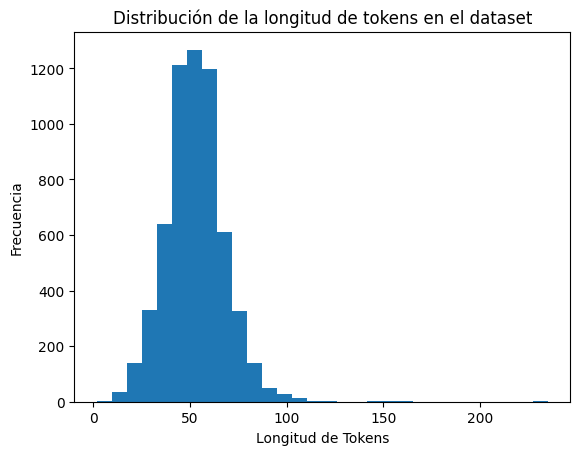

In [29]:
import matplotlib.pyplot as plt

#token_lens = [len(tokenizer.tokenize(text)) for text in X_train['transcription_processed']]
token_lens = [len(tokenizer.tokenize(text)) for text in X['transcription_processed']]

plt.hist(token_lens, bins=30)
plt.xlabel('Longitud de Tokens')
plt.ylabel('Frecuencia')
plt.title('Distribución de la longitud de tokens en el dataset')
plt.show()

Caso - max_length recomendado

Textos cortos (~50 tokens) - 64

Textos medios (~100-200 tokens) - 128

Textos largos (>300 tokens) - 256 o más (si la memoria lo permite)

Uso en GPU con 8GB VRAM - 128

Uso en CPU 64 o - 128

# Tokenization

In [30]:
max_seq_len = 64

In [31]:
# Tokenizar textos con Transformer
#encodings = tokenizer(X_train['transcription_processed'].tolist(), padding=True, truncation=True, max_length=max_seq_len, return_tensors="pt")
encodings = tokenizer(X['transcription_processed'].tolist(), padding=True, truncation=True, max_length=max_seq_len, return_tensors="pt")

In [32]:
# Crear Dataset combinando Transformer + TF-IDF + Características adicionales
labels = torch.tensor(y.values)

dataset = TensorDataset(encodings['input_ids'], encodings['attention_mask'], normalized_tensor, labels)

In [33]:
# Dividir en entrenamiento y validación
train_size = int(0.8 * len(dataset))
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, len(dataset) - train_size])

In [34]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Freeze BERT Parameters

In [35]:
# freeze all the parameters
for param in bert.parameters():
    param.requires_grad = False

# Define Model Architecture

In [36]:
class BERT_Arch(nn.Module):

    def __init__(self, bert, num_additional_features): # Added num_additional_features

      super(BERT_Arch, self).__init__()

      self.bert = bert
      self.num_additional_features = num_additional_features # Store the number of additional features

      # dropout layer
      self.dropout = nn.Dropout(0.1)

      # relu activation function
      self.relu =  nn.ReLU()

      # dense layer 1
      self.fc1 = nn.Linear(bert.config.hidden_size + self.num_additional_features, 512) # Modified

      # dense layer 2 (Output layer)
      self.fc2 = nn.Linear(512, 2)

      #softmax activation function
      self.softmax = nn.LogSoftmax(dim=1)

    #define the forward pass
    def forward(self, sent_id, mask, normalized_features): # Added normalized_features

      #pass the inputs to the model
      outputs = self.bert(sent_id, attention_mask=mask)
      cls_hs = outputs.pooler_output

      cls_hs = cls_hs.type(torch.float32)

      # Concatenate BERT output with additional features
      x = torch.cat((cls_hs, normalized_features), dim=1) # Concatenation

      x = self.fc1(x)

      x = self.relu(x)

      x = self.dropout(x)

      # output layer
      x = self.fc2(x)

      # apply softmax activation
      x = self.softmax(x)

      return x


In [37]:
# pass the pre-trained BERT to our define architecture
num_additional_features = normalized_tensor.shape[1]
model = BERT_Arch(bert, num_additional_features) # Pass num_additional_features

# push the model to GPU
model = model.to(device)

In [38]:
# define the optimizer
optimizer = AdamW(model.parameters(), lr = 1e-3)

# Find Class Weights

In [39]:
# compute the class weights of train_dataset

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Extract labels from the training dataset
train_labels = [label.item() for _, _, _, label in train_dataset]

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)

class_weights


array([0.94637224, 1.06007067])

In [40]:
# Convert class weights to a tensor
weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

# loss function
cross_entropy  = nn.NLLLoss(weight=weights)

# Fine-Tune BERT

In [41]:
def train():

  model.train()

  total_loss, total_accuracy = 0, 0

  # empty list to save model predictions
  total_preds=[]

  # iterate over batches
  for step,batch in enumerate(train_dataloader):

    # progress update after every 50 batches.
    if step % 50 == 0 and not step == 0:
      print('  Batch {:>5,}  of  {:>5,}.'.format(step, len(train_dataloader)))

    # push the batch to gpu
    batch = [r.to(device) for r in batch]

    sent_id, mask, normalized_tensor_batch, labels = batch # unpack normalized_tensor_batch

    # clear previously calculated gradients
    model.zero_grad()

    # get model predictions for the current batch
    preds = model(sent_id, mask, normalized_tensor_batch) # Pass normalized_tensor_batch

    # compute the loss between actual and predicted values
    loss = cross_entropy(preds, labels)

    # add on to the total loss
    total_loss = total_loss + loss.item()

    # backward pass to calculate the gradients
    loss.backward()

    # clip the the gradients to 1.0. It helps in preventing the exploding gradient problem
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    # update parameters
    optimizer.step()

    # model predictions are stored on GPU. So, push it to CPU
    preds=preds.detach().cpu().numpy()

    # append the model predictions
    total_preds.append(preds)

  # compute the training loss of the epoch
  avg_loss = total_loss / len(train_dataloader)

  # predictions are in the form of (no. of batches, size of batch, no. of classes).
  # reshape the predictions in form of (number of samples, no. of classes)
  total_preds  = np.concatenate(total_preds, axis=0)

  #returns the loss and predictions
  return avg_loss, total_preds

In [42]:
#ESTE SI
# function for evaluating the model
def evaluate():
    print("\nEvaluating...")
    model.eval()
    total_loss, total_accuracy = 0, 0
    total_preds = []
    true_labels = []  # Store true labels

    for step, batch in enumerate(val_dataloader):
        if step % 50 == 0 and not step == 0:
            print('  Batch {:>5,}  of  {:>5,}.'.format(step, len(val_dataloader)))

        batch = [t.to(device) for t in batch]
        sent_id, mask, normalized_tensor_batch, labels = batch

        with torch.no_grad():
            preds = model(sent_id, mask, normalized_tensor_batch)
            loss = cross_entropy(preds, labels)
            total_loss += loss.item()

            preds = preds.detach().cpu().numpy()
            total_preds.append(preds)
            true_labels.extend(labels.cpu().numpy())  # Store true labels for each batch

    avg_loss = total_loss / len(val_dataloader)
    total_preds = np.concatenate(total_preds, axis=0)
    predicted_labels = np.argmax(total_preds, axis=1)

    # Calculate metrics
    accuracy = accuracy_score(true_labels, predicted_labels)
    f1_weighted = classification_report(true_labels, predicted_labels, output_dict=True)['weighted avg']['f1-score']

    print(f"Accuracy: {accuracy:.5f}")
    print(f"Weighted F1-Score: {f1_weighted:.5f}")
    print(classification_report(true_labels, predicted_labels, digits=5))

    # Confusion Matrix
    #cm = confusion_matrix(true_labels, predicted_labels)
    #plt.figure(figsize=(8, 6))
    #sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    #plt.xlabel("Predicted")
    #plt.ylabel("Actual")
    #plt.title("Confusion Matrix")
    #plt.show()

    #return avg_loss, total_preds
    return avg_loss, total_preds, accuracy, f1_weighted # Return accuracy and f1

# Start Model Training

In [43]:
# grabar el modelo en cada epoca

# ESTE OK

# # Start Model Training
# set initial loss to infinite
best_valid_loss = float('inf')
epochs = 100 # Set the desired maximum number of epochs
patience = 2 # Number of epochs to wait for improvement
patience_counter = 0 # Counter to track the number of epochs without improvement

# empty lists to store training and validation loss of each epoch
train_losses=[]
valid_losses=[]

# Create a DataFrame to store the results
results_df = pd.DataFrame(columns=['Epoch', 'Training Loss', 'Validation Loss'])

# Create a directory to save models if it doesn't exist
#save_dir = "saved_models"
save_dir = "/content/drive/MyDrive/SatiSPeech2025/TFIDF_Plus/conLema/Transformer/fase2_ftselect/bert_multi/"
#os.makedirs(save_dir, exist_ok=True)

# Check if the directory exists and is not empty
if os.path.exists(save_dir) and os.listdir(save_dir):
    # Delete the contents of the directory
    for filename in os.listdir(save_dir):
        file_path = os.path.join(save_dir, filename)
        try:
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)
            elif os.path.isdir(file_path):
                shutil.rmtree(file_path)
        except Exception as e:
            print('Failed to delete %s. Reason: %s' % (file_path, e))
    print(f"Contents of '{save_dir}' deleted successfully.")


#for each epoch
for epoch in range(epochs):

    print('\n Epoch {:} / {:}'.format(epoch + 1, epochs))

    #train model
    train_loss, _ = train()

    #evaluate model
    #valid_loss, _ = evaluate()
    valid_loss, _, accuracy, f1_weighted = evaluate() # Modified to unpack all returned values

    #save the best model and check for early stopping
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        # Save the model for each epoch with improved validation loss
        model_path = os.path.join(save_dir, f"saved_weights_epoch_{epoch+1}.pt")
        torch.save(model.state_dict(), model_path)
        patience_counter = 0 # Reset patience counter if validation loss improves
    else:
        patience_counter += 1 # Increment patience counter if no improvement

    # append training and validation loss
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    # append training and validation loss
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    # Append the results to the DataFrame using pd.concat
    #results_df = pd.concat([results_df, pd.DataFrame({'Epoch': [epoch + 1], 'Training Loss': [train_loss], 'Validation Loss': [valid_loss]})], ignore_index=True)

    results_df = pd.concat([results_df, pd.DataFrame({'Epoch': [epoch + 1],
                                                        'Training Loss': [train_loss],
                                                        'Validation Loss': [valid_loss],
                                                        'Accuracy': [accuracy],
                                                        'F1_Weighted': [f1_weighted]})], ignore_index=True)

    print(f'\nTraining Loss: {train_loss:.3f}')
    print(f'Validation Loss: {valid_loss:.3f}')

    # Early stopping check
    if patience_counter >= patience: # Stop if no improvement for patience epochs (adjust as needed)
        print("Early stopping triggered!")
        break
results_df



 Epoch 1 / 100
  Batch    50  of    150.
  Batch   100  of    150.

Evaluating...
Accuracy: 0.88417
Weighted F1-Score: 0.88415
              precision    recall  f1-score   support

           0    0.88819   0.89241   0.89029       632
           1    0.87965   0.87500   0.87732       568

    accuracy                        0.88417      1200
   macro avg    0.88392   0.88370   0.88380      1200
weighted avg    0.88415   0.88417   0.88415      1200


Training Loss: 0.400
Validation Loss: 0.282

 Epoch 2 / 100
  Batch    50  of    150.
  Batch   100  of    150.

Evaluating...
Accuracy: 0.89667
Weighted F1-Score: 0.89667
              precision    recall  f1-score   support

           0    0.94718   0.85127   0.89667       632
           1    0.85127   0.94718   0.89667       568

    accuracy                        0.89667      1200
   macro avg    0.89922   0.89922   0.89667      1200
weighted avg    0.90178   0.89667   0.89667      1200


Training Loss: 0.210
Validation Loss: 0.265


,Epoch,Training Loss,Validation Loss,Accuracy,F1_Weighted
0,1,0.399746,0.281528,0.884167,0.884150
1,2,0.210257,0.265496,0.896667,0.896667
2,3,0.145580,0.251247,0.904167,0.904100
3,4,0.107744,0.352003,0.891667,0.890787
4,5,0.091031,0.424115,0.882500,0.881288


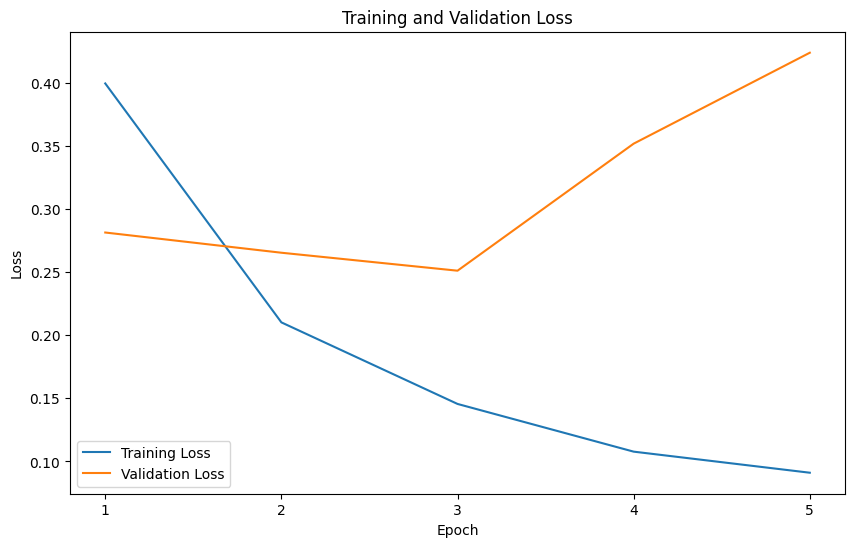

In [44]:
# graficar results_df

import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
plt.plot(results_df['Epoch'], results_df['Training Loss'], label='Training Loss')
plt.plot(results_df['Epoch'], results_df['Validation Loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
# Set x-axis ticks to be integers from 1 to the maximum epoch
plt.xticks(range(1, len(results_df) + 1))
#plt.grid(True)
plt.show()


In [45]:
# save vectorizer and scaler

import joblib

dir = "/content/drive/MyDrive/SatiSPeech2025/TFIDF_Plus/conLema/Transformer/fase2_ftselect/bert_multi/"

# Save the vectorizer
joblib.dump(vectorizer, dir + 'vectorizer.pkl')

# Save the scaler
joblib.dump(scaler, dir + 'scaler.pkl')


['/content/drive/MyDrive/SatiSPeech2025/TFIDF_Plus/conLema/Transformer/fase2_ftselect/bert_multi/scaler.pkl']



---

#**DESDE AQUÍ PARA PREDECIR CON df_test**

## Load Saved Model

In [46]:
dir = "/content/drive/MyDrive/SatiSPeech2025/TFIDF_Plus/conLema/Transformer/fase2_ftselect/bert_multi/"

In [47]:
# cargar el modelo saved_weights_epoch_ con terminacion mas alta, almacenado en dir

import os
import re

def find_latest_epoch(directory):
  """Finds the latest epoch number from saved model files."""
  epoch_numbers = []
  for filename in os.listdir(directory):
    match = re.search(r"saved_weights_epoch_(\d+).pt", filename)
    if match:
      epoch_numbers.append(int(match.group(1)))
  if not epoch_numbers:
    return None  # No saved models found
  return max(epoch_numbers)

latest_epoch = find_latest_epoch(dir)

if latest_epoch is not None:
  best = os.path.join(dir, f"saved_weights_epoch_{latest_epoch}.pt")
  print(f"Loading the best model from epoch {latest_epoch}: {best}")
  model.load_state_dict(torch.load(best))
else:
  print("No saved models found in the specified directory.")


Loading the best model from epoch 3: /content/drive/MyDrive/SatiSPeech2025/TFIDF_Plus/conLema/Transformer/fase2_ftselect/bert_multi/saved_weights_epoch_3.pt


In [48]:
# cargar scaler y vectorizer

import joblib

# Load the vectorizer
vectorizer = joblib.load(dir + 'vectorizer.pkl')

# Load the scaler
scaler = joblib.load(dir + 'scaler.pkl')


## Get Predictions for Test Data

In [49]:
df_test = pd.read_json(path + 'df_test2_featselect2.jsonl', orient='records', lines=True)

In [50]:
# Rename the 'uid' column to 'id' in df_train
df_test = df_test.rename(columns={'uid': 'id'})


In [51]:
df_test

,id,transcription,transcription_processed,MeanWordLen,LexicalDiversity,MeanSentenceLen,StdevSentenceLen,DocumentLen,WordsPerText,SentencesPerText,...,irony_score,prop_NOUN,prop_VERB,prop_ADJ,rhetorical_questions,avg_depth,Flesch Score,Lexical Entropy,Syntactic Repetition,Unusual Word Frequency
0,fa8196b4-166b7bb9.mp3,La Comunidad de Madrid hace frente así a la sa...,comunidad madrid hacer frente así saturación p...,7.107143,100.000000,17.500000,7.500000,239,28,2,...,0.773750,0.228571,0.228571,0.200000,0,2.000000,77.28,4.74,0.20,0.77
1,b407b2e7-63887829.mp3,Los féretros han sido trasladados a Chiclana y...,"féretro ser trasladar chiclana granada , ciuda...",7.161290,93.548387,7.600000,3.878144,262,31,5,...,0.787030,0.184211,0.236842,0.157895,0,1.000000,69.20,4.76,0.18,0.55
2,91cfff91-f54d3c31.mp3,"Esto que parece una obviedad, ser contundentes...","parecer obviedad , ser contundente menor indic...",6.903226,100.000000,18.000000,2.000000,253,31,2,...,0.746201,0.333333,0.194444,0.138889,0,3.000000,67.74,4.98,0.25,0.58
3,27e25c21-1cf4072b.mp3,Usted mismo reconoce que cada vez se parece má...,usted mismo reconocer cada vez parecer fragar ...,6.171429,85.714286,14.333333,9.843215,264,35,3,...,0.525862,0.232558,0.302326,0.046512,1,1.666667,85.24,4.91,0.19,0.56
4,bb4ddfe5-fe837a69.mp3,Vamos a escuchar a todos los miembros del Comi...,"ir escuchar miembro comité federal , punto , ,...",6.648649,86.486486,16.666667,13.199327,306,37,3,...,0.784765,0.240000,0.180000,0.120000,0,6.666667,92.56,4.76,0.26,0.53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0dc2352f-e334aca3.mp3,"Tratan de superarlo en estos centros, pero a d...","tratar superar él centro , día hoy rachidi jul...",5.235294,88.235294,19.000000,0.000000,109,17,1,...,0.679542,0.157895,0.421053,0.000000,0,8.000000,88.48,4.00,0.26,0.53
1996,830f9896-e3b18f45.mp3,"Afuera, seguidores del partido de extrema dere...","afuero , seguidor partido extremo derecha aman...",6.956522,100.000000,9.666667,1.885618,192,23,3,...,0.636896,0.344828,0.137931,0.241379,0,2.666667,89.54,4.53,0.24,0.64
1997,31c41168-febf1975.mp3,"Niña, una muestra que reúne 48 obras de arte c...","niña , muestra reúnir obra arte contemporáneo ...",6.818182,100.000000,13.500000,2.500000,180,22,2,...,0.667856,0.296296,0.222222,0.148148,0,4.000000,86.09,4.50,0.22,0.67
1998,975631e6-fb7e4017.mp3,Pero no hemos conseguido esa respuesta unida q...,conseguir respuesta unido conseguir guerra ucr...,6.631579,89.473684,11.000000,4.000000,149,19,2,...,0.611322,0.272727,0.227273,0.181818,0,0.500000,76.13,4.19,0.32,0.53


In [52]:
# Get Predictions for Test Data

# Extraer características TF-IDF para los datos de prueba
X_tfidf_test = vectorizer.transform(df_test['transcription_processed']).toarray()

# Crear DataFrame para las características TF-IDF de prueba
X_tfidf_test_df = pd.DataFrame(X_tfidf_test)

# Convertir nombres de columna a cadenas
X_tfidf_test_df.columns = X_tfidf_test_df.columns.astype(str)

# Separar características adicionales del conjunto de datos de prueba
df_caract_test = df_test.iloc[:, 3:]

# Concatenar características TF-IDF y características adicionales para datos de prueba
concatenated_test_df = pd.concat([X_tfidf_test_df, df_caract_test], axis=1)

# Imputar valores faltantes con la media de cada columna (igual que en el conjunto de entrenamiento)
concatenated_test_df = concatenated_test_df.fillna(concatenated_df.mean())  # Usar la media del conjunto de entrenamiento

# Normalizar los datos de prueba utilizando el mismo MinMaxScaler del conjunto de entrenamiento
normalized_test_df = scaler.transform(concatenated_test_df)

# Convertir a tensor de PyTorch
normalized_test_tensor = torch.tensor(normalized_test_df, dtype=torch.float32)

# Tokenizar los textos de prueba
encodings_test = tokenizer(df_test['transcription_processed'].tolist(), padding=True, truncation=True, max_length=max_seq_len, return_tensors="pt")

# Crear conjunto de datos para los datos de prueba
test_dataset = TensorDataset(encodings_test['input_ids'], encodings_test['attention_mask'], normalized_test_tensor)

# Crear DataLoader para los datos de prueba
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)


# Función para obtener predicciones
def get_predictions():
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch in test_dataloader:
            batch = [t.to(device) for t in batch]
            inputs = {'sent_id': batch[0], 'mask': batch[1], 'normalized_features': batch[2]}
            outputs = model(**inputs)
            _, predicted = torch.max(outputs, 1)
            predictions.extend(predicted.cpu().numpy())
    return predictions


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Obtener predicciones
test_predictions = get_predictions()
test_predictions


[np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.in

In [53]:
#GENERA LA SALIDA PARA EL WORKSHOP
output_df = pd.DataFrame(columns=["id", "task_1", "task_2"])
output_df["id"] = df_test["id"].str.replace ('.mp3', '', regex = False)
output_df["task_1"] = test_predictions
output_df["task_2"] = test_predictions
output_df["task_1"] = output_df["task_1"].map({0: 'no-satire', 1: 'satire'})
output_df["task_2"] = output_df["task_2"].map({0: 'no-satire', 1: 'satire'})
print (output_df)
output_df.to_csv (os.path.join(dir, 'results.csv'), index = False)

                     id     task_1     task_2
0     fa8196b4-166b7bb9     satire     satire
1     b407b2e7-63887829  no-satire  no-satire
2     91cfff91-f54d3c31  no-satire  no-satire
3     27e25c21-1cf4072b  no-satire  no-satire
4     bb4ddfe5-fe837a69     satire     satire
...                 ...        ...        ...
1995  0dc2352f-e334aca3     satire     satire
1996  830f9896-e3b18f45     satire     satire
1997  31c41168-febf1975  no-satire  no-satire
1998  975631e6-fb7e4017  no-satire  no-satire
1999  af48d481-d8b8db3c     satire     satire

[2000 rows x 3 columns]
